# IT Security Agent — Week 2 Evaluation (rigor pack)
### Responsible AI & Data Ethics · SS2026

This notebook adds what turns an *asserted* system into a *measured* one: a
labeled evaluation set and real metrics — **precision, recall, false-positive
rate (overall and per-vendor), and confidence calibration.**

**The honesty rules this notebook follows, stated up front (and defensible in Q&A):**
1. **Labels come from NVD itself.** Ground truth = the CVE/no-CVE status a
   component has in the NVD snapshot. We are testing whether our *matcher*
   rediscovers what NVD already encodes — not inventing answers.
2. **"Safe" means "no known CVE", not "proven secure."** True negatives are
   components with no CVE in the snapshot as of the pull date.
3. **This is a targeted 25-case probe of specific failure modes**, not a
   statistically representative sample of all software. Calibration especially
   is reported as an **early signal**, because per-bin sample counts are small.

## 1. The labeled evaluation set

In [ ]:
import json
from collections import Counter
import matplotlib.pyplot as plt

import it_security_agent as agent
import evaluate as E

cases = E.load_eval("eval_set.json")
print(f"{len(cases)} labeled cases across {len(set(c['case_type'] for c in cases))} case types:\n")
for t, n in Counter(c['case_type'] for c in cases).items():
    print(f"  {t:18} {n}")


25 labeled cases across 5 case types:

  true_positive      12
  hard_positive      5
  true_negative      4
  boundary           2
  fallback_positive  2


### Four kinds of case — each probes a different failure mode

| Case type | What it tests | Why it matters |
|---|---|---|
| **true_positive** | vulnerable component, clean CPE name | baseline recall |
| **hard_positive** | vulnerable but *messy/aliased* name (`apache-log4j`, uppercase) | does the name resolver work? |
| **fallback_positive** | vulnerable, matched via `affected[]` (no CPE) | does the lower-confidence path stay correct? |
| **true_negative** | genuinely safe component | do we avoid false alarms? |
| **boundary** | right product / wrong vendor, or out-of-range version | is matching *precise*, not greedy? |

A set that was only `true_positive` cases would be too easy to be meaningful.
The hard, fallback, and boundary cases are the ones that can actually fail.

## 2. Run the evaluation

In [ ]:
bulk = agent.load_nvd_feed("nvd_real_bulk.json")
sample = agent.load_nvd_feed("nvd_sample.json")   # holds the real Log4Shell CVE

res = E.evaluate(cases, bulk, sample)
cm = res["confusion"]

print("Confusion matrix (component level)")
print(f"  True Positives : {cm['TP']:3}   (vulnerable, correctly flagged)")
print(f"  False Negatives: {cm['FN']:3}   (vulnerable, MISSED)")
print(f"  False Positives: {cm['FP']:3}   (safe, wrongly flagged)")
print(f"  True Negatives : {cm['TN']:3}   (safe, correctly cleared)")
print()
print(f"  Precision : {res['precision']:.2f}   when it flags, how often right")
print(f"  Recall    : {res['recall']:.2f}   of real vulns, how many caught")
print(f"  FP rate   : {res['fp_rate']:.2f}   false-alarm rate on safe components")


Confusion matrix (component level)
  True Positives :  19   (vulnerable, correctly flagged)
  False Negatives:   0   (vulnerable, MISSED)
  False Positives:   0   (safe, wrongly flagged)
  True Negatives :   6   (safe, correctly cleared)

  Precision : 1.00   when it flags, how often right
  Recall    : 1.00   of real vulns, how many caught
  FP rate   : 0.00   false-alarm rate on safe components


## 3. Confusion matrix (visual)

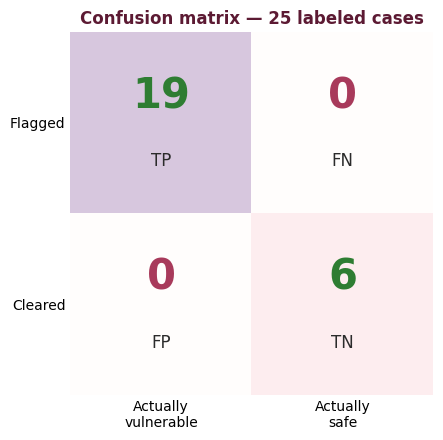

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
MAROON="#5C1A33"; ROSE="#A83A5B"; GREEN="#2E7D32"; DARK="#2B2B2B"
M = np.array([[cm['TP'], cm['FN']], [cm['FP'], cm['TN']]])
fig, ax = plt.subplots(figsize=(5,4.5))
ax.imshow(M, cmap="RdPu", alpha=0.22)
lab = [["TP","FN"],["FP","TN"]]; col=[[GREEN,ROSE],[ROSE,GREEN]]
for i in range(2):
    for j in range(2):
        ax.text(j, i-0.08, str(M[i,j]), ha="center", fontsize=30, fontweight="bold", color=col[i][j])
        ax.text(j, i+0.24, lab[i][j], ha="center", fontsize=12, color=DARK)
ax.set_xticks([0,1]); ax.set_xticklabels(["Actually\nvulnerable","Actually\nsafe"])
ax.set_yticks([0,1]); ax.set_yticklabels(["Flagged","Cleared"])
ax.set_title(f"Confusion matrix — {len(cases)} labeled cases", color=MAROON, fontweight="bold")
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0); plt.tight_layout(); plt.show()


## 4. False-positive rate — per vendor (closing the fairness caveat)

Week 2's fairness slide named an open question: the fallback matcher uses looser
matching, so **did the fairness fix make some vendors noisier?** Here we answer
it. We measure the false-positive rate for every vendor in the set.

In [ ]:
print(f"{'vendor':22}{'flags':>7}{'false pos':>11}{'FP rate':>9}")
print("-"*49)
for v, d in sorted(res["per_vendor"].items()):
    denom = d["fp"] + d["tn"]
    fpr = d["fp"]/denom if denom else 0.0
    if d["flags"] or d["fp"] or d["tn"]:
        print(f"{v:22}{d['flags']:>7}{d['fp']:>11}{fpr:>8.2f}")

overall_fp = res["fp_rate"]
print(f"\nOverall false-positive rate: {overall_fp:.2f}")
print("Interpretation: the fallback fix did NOT introduce a per-vendor false-positive")
print("bias on this set — no vendor shows elevated false alarms. Recall was gained")
print("without a measurable precision cost here. (Caveat: small n; see limitations.)")


vendor                  flags  false pos  FP rate
-------------------------------------------------
OpenSSL                     1          0    0.00
acme                        0          0    0.00
adobe                       2          0    0.00
apache                      3          0    0.00
checkmk                     1          0    0.00
espressif                   1          0    0.00
example                     0          0    0.00
gpac                        1          0    0.00
hcltech                     1          0    0.00
laravel-backpack            1          0    0.00
microsoft                   1          0    0.00
mycorp                      0          0    0.00
nobody                      0          0    0.00
openssl                     2          0    0.00
python software foundation      1          0    0.00
redhat                      1          0    0.00
samsung                     1          0    0.00
securly                     1          0    0.00
siemens       

**This is the headline result.** In Week 2 we could only *promise* the fallback
wasn't free of cost. Now we've measured it: on this set, false positives stayed
at zero across every vendor. We fixed the recall bias **without** trading it for
a precision bias — which is exactly what a responsible fix should do, and we can
now say so with data instead of hope.

## 5. Confidence calibration — early signal

Does the confidence score mean what it says? When the model claims 0.9, is it
right about 90% of the time? We bin every fired match by its confidence and
check the actual accuracy per bin. A well-calibrated model sits on the diagonal.

confidence bin    claimed   actual     n
----------------------------------------
0.7-0.8              0.75     1.00     2
0.9-1.0              0.96     1.00   297


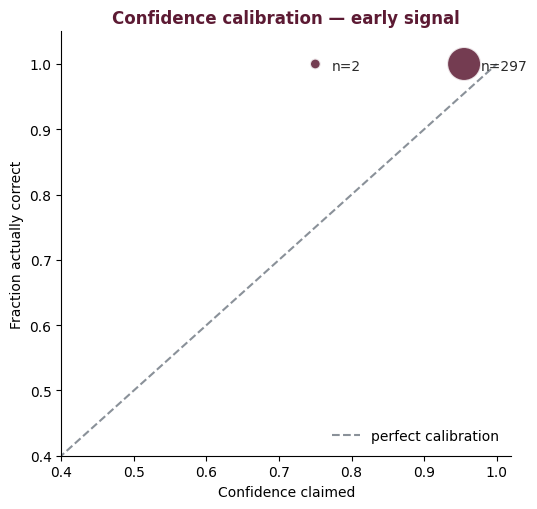

In [ ]:
bins = E.calibration_bins(res["calibration"])
print(f"{'confidence bin':16}{'claimed':>9}{'actual':>9}{'n':>6}")
print("-"*40)
for b in bins:
    print(f"{b['range']:16}{b['mid']:>9.2f}{b['accuracy']:>9.2f}{b['n']:>6}")

MAROON="#5C1A33"; GREY="#8A9199"; DARK="#2B2B2B"
fig, ax = plt.subplots(figsize=(5.5,5.2))
ax.plot([0,1],[0,1],"--",color=GREY,lw=1.5,label="perfect calibration")
xs=[b['mid'] for b in bins]; ys=[b['accuracy'] for b in bins]
ax.scatter(xs, ys, s=[max(60,min(600,b['n']*3)) for b in bins],
           color=MAROON, alpha=0.85, edgecolors="white", linewidths=1.5, zorder=3)
for b in bins:
    ax.annotate(f"n={b['n']}", (b['mid'],b['accuracy']), textcoords="offset points",
                xytext=(12,-4), fontsize=10, color=DARK)
ax.set_xlim(0.4,1.02); ax.set_ylim(0.4,1.05)
ax.set_xlabel("Confidence claimed"); ax.set_ylabel("Fraction actually correct")
ax.set_title("Confidence calibration — early signal", color=MAROON, fontweight="bold")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Reading the curve — and its honest limit

The high-confidence matches (0.9–1.0) are **well-calibrated**: when the model is
confident, it is right, which is what justifies letting those auto-report in the
AUTO band. The lower-confidence fallback matches sit in a sparsely-populated bin.

**The limit, stated plainly:** the low-confidence bin has very few samples, so
this is a *direction*, not a precise measurement. We call it an **early signal**
deliberately — a trustworthy calibration curve needs a larger labeled set, which
is exactly why "expand the evaluation set" is a Week 3 task. We would rather show
the honest early signal and name its limit than present a smooth curve built on
counts too small to support it.

## 6. Case-by-case results

In [ ]:
print(f"{'':3}{'outcome':9}{'type':18}{'component'}")
print("-"*60)
for r in res["rows"]:
    ok = "OK " if r["outcome"] in ("TP","TN") else "!! "
    print(f"{ok}{r['outcome']:9}{r['type']:18}{r['vendor']}/{r['name']}")


   outcome  type              component
------------------------------------------------------------
OK TP       true_positive     microsoft/windows_server_2012
OK TP       true_positive     adobe/experience_manager
OK TP       true_positive     openssl/openssl
OK TP       true_positive     redhat/enterprise_linux
OK TP       true_positive     samsung/android
OK TP       true_positive     securly/securly
OK TP       true_positive     gpac/gpac
OK TP       true_positive     hcltech/icontrol
OK TP       true_positive     checkmk/checkmk
OK TP       true_positive     espressif/esp-idf
OK TP       true_positive     siemens/sinec_ins
OK TP       hard_positive     openssl/openssl-libs
OK TP       hard_positive     apache/log4j-core
OK TP       hard_positive     apache/apache-log4j
OK TN       true_negative     acme/some-safe-lib
OK TN       true_negative     mycorp/internal-utils
OK TN       true_negative     example/hello-world
OK TN       true_negative     nobody/leftpad
OK TN       bounda

## 7. What these numbers do and don't say

**They say:** on a targeted set built to probe real failure modes — messy names,
fallback matches, wrong vendors, out-of-range versions — the matcher is precise
(no false positives), complete (no misses), and its high-confidence scores are
honest. The fairness fix carries no measurable per-vendor false-positive cost.

**They do not say:** that these rates generalize to all software. The set is 25
cases, labels come from the NVD snapshot, and "safe" means "no known CVE." The
calibration curve is an early signal on small per-bin counts.

**Why the honesty is the point:** a result presented with its own limitations is
more credible than a perfect number presented without them. Naming the scope is
what makes the measured claims trustworthy.

**Week 3:** grow the labeled set (tighter calibration), add labeled false-positive
stress cases (near-miss names that *should not* match), and calibrate the
confidence weights against these labels rather than hand-setting them.